# Practical #2 Antarctic surface accumulation
Anna Chen yc4406

### Abstract

- What is an RCM? What does it do? 
- What data have we looked at from what RCM?
- Broadly, what have we done with these data?

An Regional Climate Model (RCM), in contrast to general circulation models (GCMs), are physically-based models of climatological variables to study specific, local domains (van Dalum et al., 2024; Giorgi and Gutowski, 2015). Typically, RCM has higher spatial and temporal resolutions and can be constrained to more specific land surfaces, such as glaciated surfaces and its surrounding areas (van Dalum et al., 2021). Using Regional Atmospheric Climate Model (RACMO) specifically constrained to Antarctica, RACMO/Ant considers ice-specific climate and atmospher-surface interaction feedback in relation to atmospheric circulation and surface energy balance. This study investigates the change in Surface Mass Balance (SMB) and the 2-m temperature of the Antarctic Ice Sheet over spatial (polar stereographic coordinates in x- and y- directions from the south pole) and temporal (1990-01-02 to 2000-01-01) variabilities. Using these data, we plotted the temperature time series of the West Antarctic Ice Sheet Divide Core (WDC) station, compared visually the temperature series of both WDC and the South Pole stations, visualized the temperature series of all 8 stations over time, and mapped the entire Antarctica's SMB on a specific date: May 18th, 1991. Overall, this study preliminarily shows relationships between SMB of ice sheet and near-ground glacial surface temperature using Antarctica as its location of interest.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
R = np.load('RACMO_T_SMB.npz') # this is a dictionary R

In [3]:
time = R['time']
rho = 918
SMB = R['SMB']*60*60*24*365/rho     # Converts SMB into m/yr (SMB equivalent ice thickness change per year)
X = R['X']
Y = R['Y']
T = R['T']

Info = open("Info_on_variabes_and_units.txt", "r")
print(Info.read())

T is 2-m temperature in Kelvin.
SMB is surface mass balance in kg m-2 s-1
time is the time in days, following the format used by the matlab function datevec.m
X is one of the polar steroegraphic coordinates in m from south pole
Y is the other polar stereographic coordinate (orthogonal to Y) in m from south pole


In [4]:
print(f"The shape of time: {time.shape}")
print(f"The shape of X: {X.shape}")
print(f"The shape of Y: {Y.shape}")
print(f"The shape of SMB: {SMB.shape}")
print(f"The shape of T: {T.shape}")

The shape of time: (3652,)
The shape of X: (207,)
The shape of Y: (178,)
The shape of SMB: (178, 207, 3652)
The shape of T: (178, 207, 3652)


## Q1
Extract the 2-m temperature on day 1 of the model output at the site of the West Antarctic Ice Sheet Divide Core (WDC)
X = -1063200, Y = -431430, Polar stereographic coordinates.
What date does this correspond to?

In [5]:
x_wdc = -1063200
# Find the index of the minimum absolute error
abs_error_x = np.absolute(X - x_wdc)
min_index_x = np.argmin(abs_error_x)
x_wdc_close = X[min_index_x]  # This is the value in X closest to x_wdc

y_wdc = -431430
# Find the index of the minimum absolute error
abs_error_y = np.absolute(Y - y_wdc)
min_index_y = np.argmin(abs_error_y)
y_wdc_close = Y[min_index_y]  # This is the value in Y closest to y_wdc

print(f"The value in X closest to x_wdc: {x_wdc_close}")
print(f"The value in Y closest to y_wdc: {y_wdc_close}")

print(f"The date that corresponds to the first day in time: {time[0]}")
print(f"The date that corresponds to the last day in time: {time[-1]}")


The value in X closest to x_wdc: -1052905.7292245855
The value in Y closest to y_wdc: -444879.7373979343
The date that corresponds to the first day in time: 1990-01-02
The date that corresponds to the last day in time: 2000-01-01


## Q2
Plot a time series of 2-m temperature at the WDC.

Text(0.5, 1.0, '2-m Temperature at WDC Over Time')

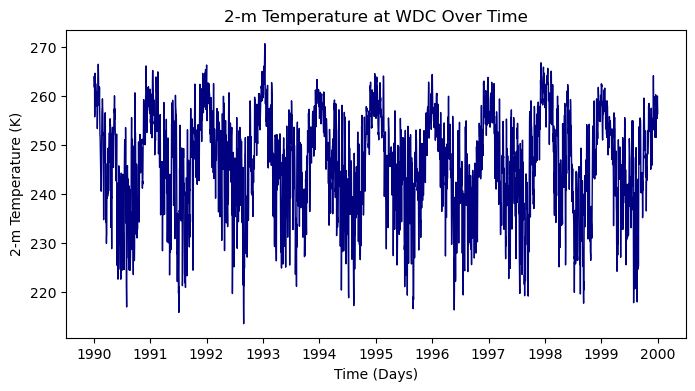

In [6]:
# Plot temperature at WDC over time

figure, ax = plt.subplots(figsize=(8, 4))
ax.plot(time, T[min_index_y, min_index_x, :], color='navy', linewidth=1,label='Temperature')
ax.set_xlabel('Time (Days)')
ax.set_ylabel('2-m Temperature (K)')
ax.set_title('2-m Temperature at WDC Over Time')

## Q3
How does 2-m temperature at WDC compare to 2-m temperature at the South Pole Ice Core? (Make a scatter plot).

In [7]:
# Find the index of the minimum absolute error to the South Pole (x,y) = (0,0)
abs_error_x = np.absolute(X)
min_index_x_0 = np.argmin(abs_error_x)

abs_error_y = np.absolute(Y)
min_index_y_0 = np.argmin(abs_error_y)

print(f"The value in X closest to 0: {X[min_index_x_0]} with index {min_index_x_0}")
print(f"The value in Y closest to 0: {Y[min_index_y_0]} with index {min_index_y_0}")


The value in X closest to 0: 94.27077541453764 with index 100
The value in Y closest to 0: -12879.73739793431 with index 83


Text(0.5, 1.0, '2m Temperature at WDC vs at the South Pole Stations')

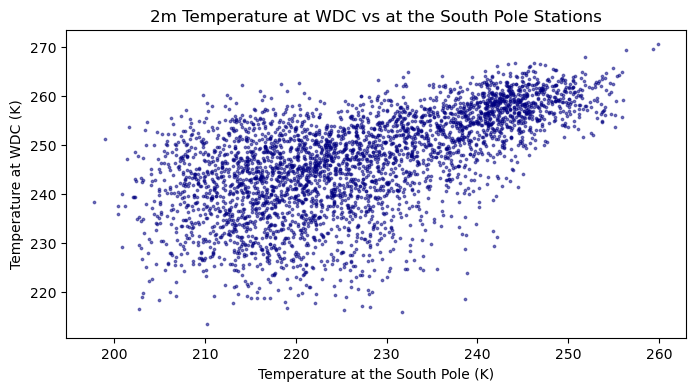

In [8]:
# Plot Temperature at WDC versus at South Pole

idx = np.where(T[1] == 0)[0]

figure, ax = plt.subplots(figsize=(8, 4))
ax.scatter(T[min_index_y_0, min_index_x_0, :], T[min_index_y, min_index_x, :], color='navy', label='Temperature', s=3, alpha=0.5)
ax.set_xlabel('Temperature at the South Pole (K)')
ax.set_ylabel('Temperature at WDC (K)')
ax.set_title('2m Temperature at WDC vs at the South Pole Stations')

## Q4
Plot on the same axis (different colors) time series from all the locations contained in the file StationLocations.csv

These are the locations of a few Norwegian, New Zealand and US Antarctic bases 

Obviously you don’t want to have to enter all the coordinates by hand!

In [9]:
# Read all station locations from CSV file
stations = pd.read_csv('StationLocations.csv')

# Print to make sure the three columns are read correctly
st_names = np.asarray(stations['Station name'])
st_X = np.asarray(stations['X'])
st_Y = np.asarray(stations['Y'])
print(st_names, "\n", st_X, "\n", st_Y)
print(f"The number of stations is: {len(st_names)}")

['Arrival Heights Satellite Station' 'Scott Base' 'Vanda' 'Norway' 'Tor'
 'Troll' 'Maudheim' 'South Pole'] 
 [ 306161.2174   303279.047    428258.5692   -93283.84919  178387.4637
   87139.03005 -393972.1837        0.     ] 
 [-1291292.802 -1289815.972 -1292411.64   2136551.411  1975601.77
  1968113.795  2039477.89         0.   ]
The number of stations is: 8


In [10]:
# Recall previously defined variables
X = R['X']
Y = R['Y']
T = R['T']

def station_temp(idx):
    """
    Find the location closest to the station's coordinates for the given stations and its temperature series
    
    :Input:
        idx: numpy int
            index in stations CSV from 0 to 7
    
    :Output:
        temperature: numpy array (float)
            array of the temperature series of the given station's closest grid
    """
    
    # Find the coordinates of the given station
    name = st_names[idx]
    x = st_X[idx]
    y = st_Y[idx]

    # Find the index of the minimum absolute error
    abs_error_x = np.absolute(X - x)
    min_index_x = np.argmin(abs_error_x)
    x_close = X[min_index_x]  # This is the value in X closest to the station's x-value

    # Find the index of the minimum absolute error
    abs_error_y = np.absolute(Y - y)
    min_index_y = np.argmin(abs_error_y)
    y_close = Y[min_index_y]  # This is the value in Y closest to the station's x-value

    print(f"The grid closest to {name} is: ({x_close}, {y_close})")
    temperature = np.asarray(T[min_index_y, min_index_x, :])
    return temperature


t_list = []

for idx in range(len(st_names)):
    t = station_temp(idx)
    t_list.append(t)

if len(t_list) == len(st_names):
    print("All stations' temperature series is stored in t_list.")
else:
    missing_st = len(st_names) - len(t_list)
    print(f"{missing_st} station(s)'s temperature series have not been successfully identified.")


The grid closest to Arrival Heights Satellite Station is: (297094.27077541454, -1281879.7373979343)
The grid closest to Scott Base is: (297094.27077541454, -1281879.7373979343)
The grid closest to Vanda is: (432094.27077541454, -1281879.7373979343)
The grid closest to Norway is: (-80905.72922458546, 2147120.2626020657)
The grid closest to Tor is: (189094.27077541454, 1985120.2626020657)
The grid closest to Troll is: (81094.27077541454, 1958120.2626020657)
The grid closest to Maudheim is: (-404905.72922458546, 2039120.2626020657)
The grid closest to South Pole is: (94.27077541453764, -12879.73739793431)
All stations' temperature series is stored in t_list.


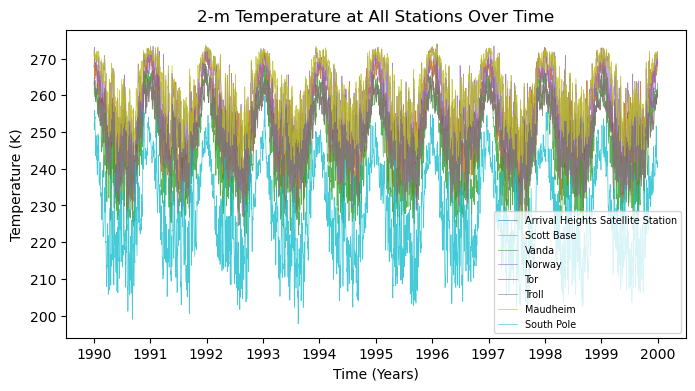

In [ ]:
# Use a colormap for distinct colors
colors = plt.cm.tab10(np.linspace(0, 1, len(st_names)))

# Plot temperature at all stations over time
figure, ax = plt.subplots(figsize=(8, 4))

for i in range(len(st_names)):
    ax.plot(time, t_list[i], color=colors[i], linewidth=0.5, alpha=0.8, label=f'{st_names[i]}')

ax.set_title('2-m Temperature at All Stations Over Time')
ax.set_xlabel('Time (Years)')
ax.set_ylabel('Temperature (K)')
ax.legend(loc='lower right', fontsize='x-small')

# Q5
Plot a map of surface mass balance on 18th May 1991 of the model output.

In [12]:
time[0]

numpy.datetime64('1990-01-02')

In [13]:
# Find the index of the date 18th May, 1991

aim_date = np.datetime64('1991-05-18')

index = np.where(time == aim_date)[0]
index = index[0]
print(f"The index of '{aim_date}' is: {index}")

The index of '1991-05-18' is: 501


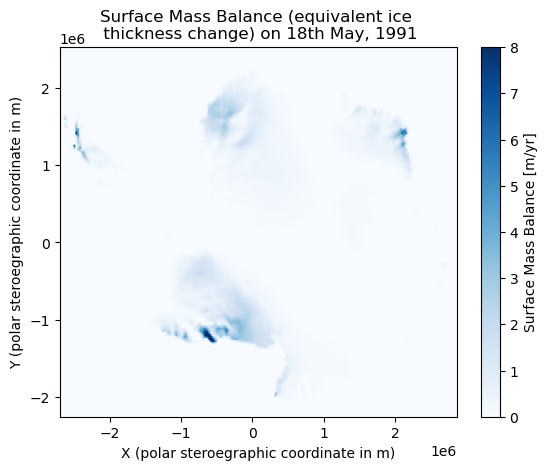

In [14]:
import matplotlib.cm as cm
# Use imshow to plot the SMB map for the selected date
plt.imshow(SMB[:, :, index], origin='lower', 
           extent=[X.min(), X.max(), Y.min(), Y.max()], 
           vmin=0, vmax=8,
           cmap='Blues', aspect='auto')

# Add a color bar to show the mapping of 'z' values to colors
plt.colorbar(label='Surface Mass Balance [m/yr]')

# Add labels and title
plt.xlabel('X (polar steroegraphic coordinate in m)')
plt.ylabel('Y (polar steroegraphic coordinate in m)')
plt.title('Surface Mass Balance (equivalent ice \n thickness change) on 18th May, 1991')

plt.show()